# Lab 05 — The Matrix Machine

## How matrices transform vectors, point clouds, images, and features

This lab is designed to accompany **Chapter 5: The Matrix Machine**.

The goal is not only to practice multiplication.  The goal is to see that a matrix is a rule for changing information.

You will explore:

1. matrix-vector multiplication by rows and by columns;
2. matrices as transformations of points and grids;
3. scaling, rotation, reflection, shear, and projection;
4. information loss;
5. feature mixing in data science;
6. image transformations;
7. high-dimensional linear maps.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


## 1. Matrix-vector multiplication

A matrix can be read row by row or column by column.

The row view says: each output coordinate is a dot product.

The column view says: the output is a linear combination of the columns.

In [2]:
A = np.array([[2, -1, 4],
              [0,  3, 5]])
x = np.array([1, 2, -1])

print("A =")
print(A)
print("x =", x)
print("A @ x =", A @ x)


A =
[[ 2 -1  4]
 [ 0  3  5]]
x = [ 1  2 -1]
A @ x = [-4  1]


In [3]:
# Row view
row_outputs = np.array([row @ x for row in A])
print("Row-view output:", row_outputs)

# Column view
columns = [A[:, j] for j in range(A.shape[1])]
column_combination = sum(x[j] * columns[j] for j in range(A.shape[1]))
print("Column-view output:", column_combination)


Row-view output: [-4  1]
Column-view output: [-4  1]


### Student task

Change the vector `x`.  Before running the code, predict whether the output will be closer to column 1, column 2, or column 3 of the matrix.

## 2. The columns tell us where the basis vectors go

For a $2 	imes 2$ matrix $A$, the first column is $Ae_1$ and the second column is $Ae_2$.

In [4]:
A = np.array([[1.0, 2.0],
              [0.0, 1.0]])
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

print("A e1 =", A @ e1)
print("A e2 =", A @ e2)
print("First column:", A[:, 0])
print("Second column:", A[:, 1])


A e1 = [1. 0.]
A e2 = [2. 1.]
First column: [1. 0.]
Second column: [2. 1.]


## 3. Visualizing one vector before and after

The following function draws an input vector and its output after applying a matrix.

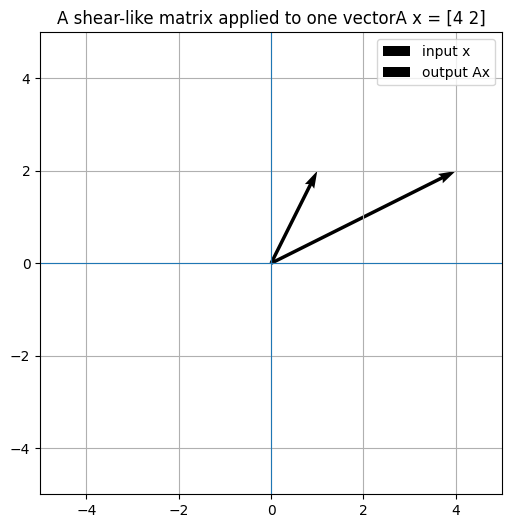

In [7]:
def draw_vector_transform(A, x, title="Vector transformation"):
    y = A @ x
    lim = max(1, np.max(np.abs([x[0], x[1], y[0], y[1]])) + 1)
    plt.figure(figsize=(6, 6))
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.grid(True)
    plt.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, label='input x')
    plt.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', scale=1, label='output Ax')
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.title(title + f"A x = {y}")
    plt.show()

A = np.array([[2, 1],
              [0, 1]])
x = np.array([1, 2])
draw_vector_transform(A, x, "A shear-like matrix applied to one vector")


## 4. Transforming a square

A matrix acts on every point.  A useful test is to apply it to the corners of a square.

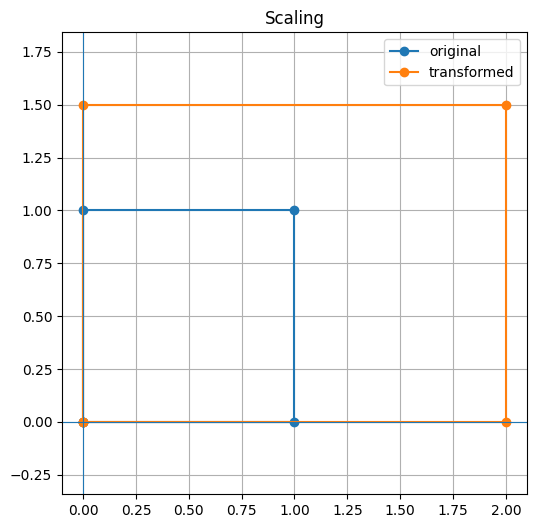

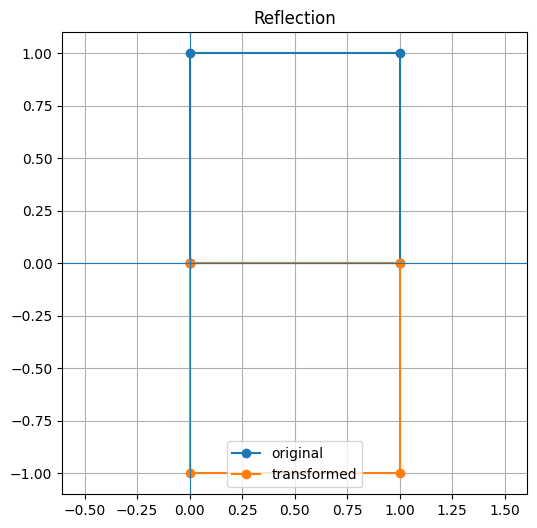

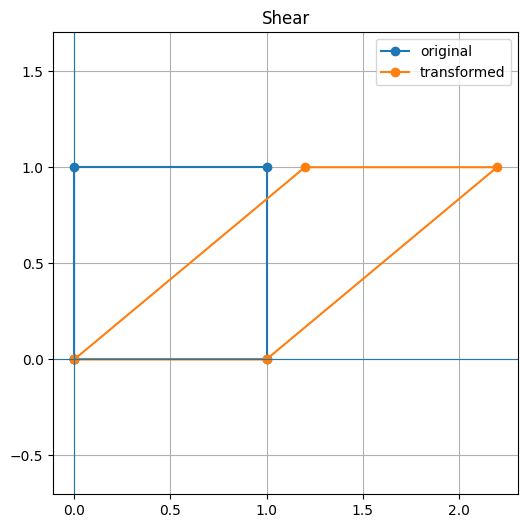

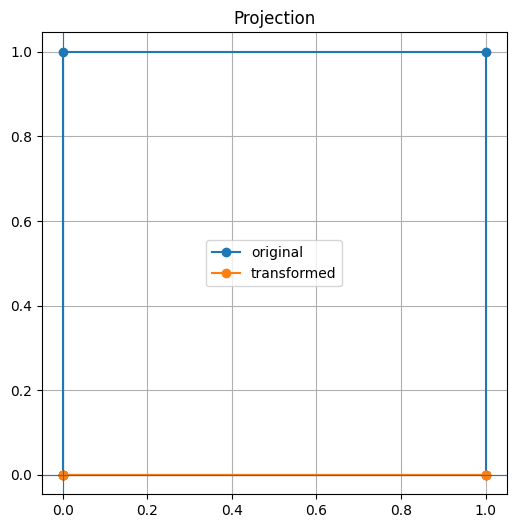

In [8]:
def plot_shape_transform(A, points, title="Shape transformation"):
    transformed = points @ A.T
    plt.figure(figsize=(6, 6))
    plt.plot(points[:, 0], points[:, 1], marker='o', label='original')
    plt.plot(transformed[:, 0], transformed[:, 1], marker='o', label='transformed')
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.title(title)
    plt.show()

square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], dtype=float)

matrices = {
    "Scaling": np.array([[2, 0], [0, 1.5]]),
    "Reflection": np.array([[1, 0], [0, -1]]),
    "Shear": np.array([[1, 1.2], [0, 1]]),
    "Projection": np.array([[1, 0], [0, 0]])
}

for name, M in matrices.items():
    plot_shape_transform(M, square, name)


## 5. The grid test

Linear transformations keep grid lines straight and parallel.
The next plot shows how a matrix transforms a whole grid.

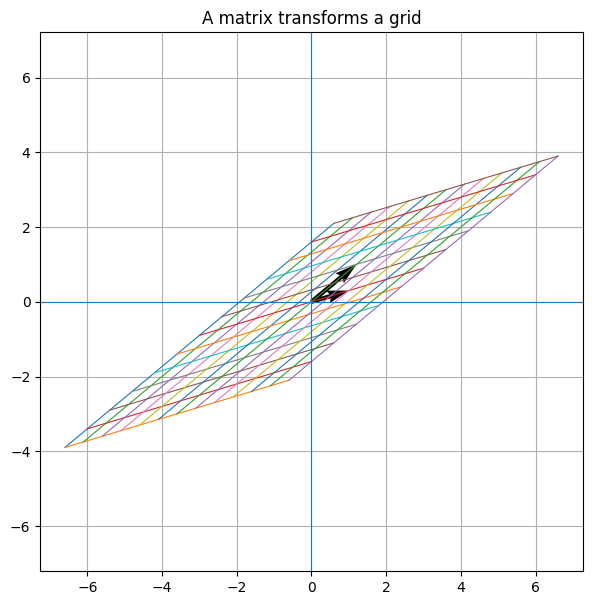

In [9]:
def plot_grid_transform(A, grid_min=-3, grid_max=3, n=13, title="Grid transformation"):
    plt.figure(figsize=(7, 7))
    values = np.linspace(grid_min, grid_max, n)
    for c in values:
        vertical = np.array([[c, grid_min], [c, grid_max]])
        horizontal = np.array([[grid_min, c], [grid_max, c]])
        Tv = vertical @ A.T
        Th = horizontal @ A.T
        plt.plot(Tv[:, 0], Tv[:, 1], linewidth=0.8)
        plt.plot(Th[:, 0], Th[:, 1], linewidth=0.8)
    Ae1 = A @ np.array([1,0])
    Ae2 = A @ np.array([0,1])
    plt.quiver(0,0,Ae1[0],Ae1[1],angles='xy',scale_units='xy',scale=1,width=0.008)
    plt.quiver(0,0,Ae2[0],Ae2[1],angles='xy',scale_units='xy',scale=1,width=0.008)
    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.axis('equal')
    plt.grid(True)
    plt.title(title)
    plt.show()

A = np.array([[1, 1.2],
              [0.3, 1]])
plot_grid_transform(A, title="A matrix transforms a grid")


### Student task

Try the following matrices and describe what you see:

```python
np.array([[2,0],[0,2]])
np.array([[0,-1],[1,0]])
np.array([[1,2],[0,1]])
np.array([[1,0],[0,0]])
```


## 6. Rotation matrices

A rotation matrix has the form

$$
Q_\theta = \begin{bmatrix}\cos	\theta & -\sin\theta \\ \sin\theta & \cos\theta\end{bmatrix}.
$$


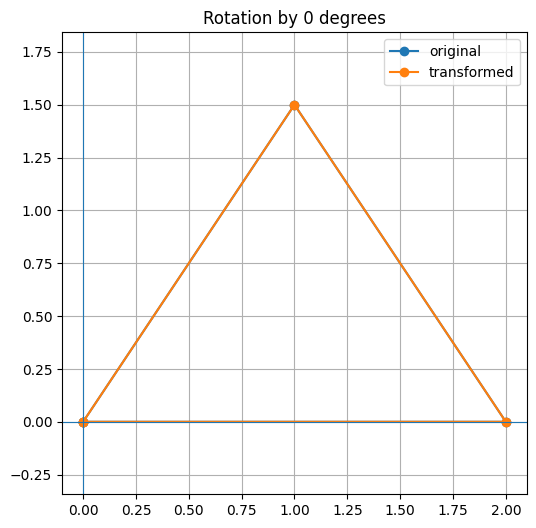

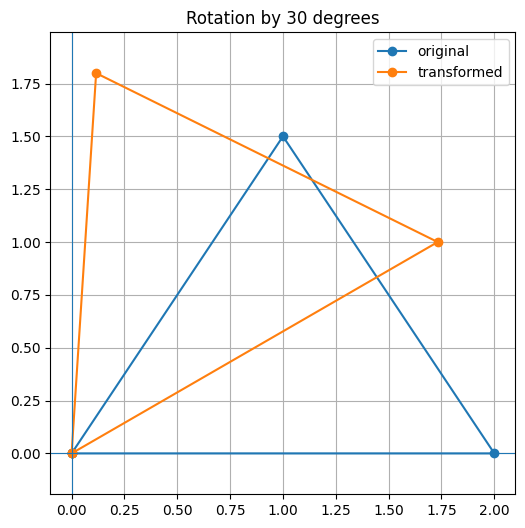

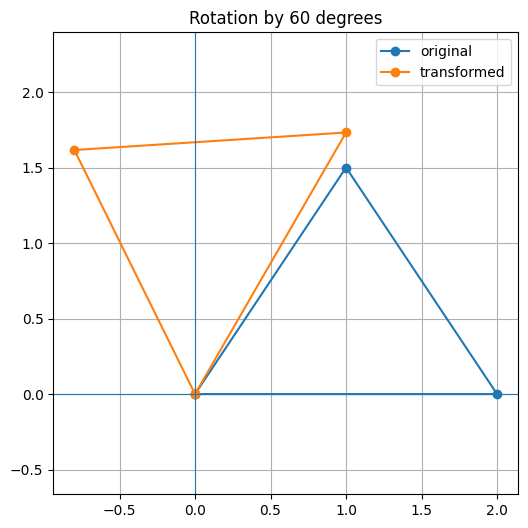

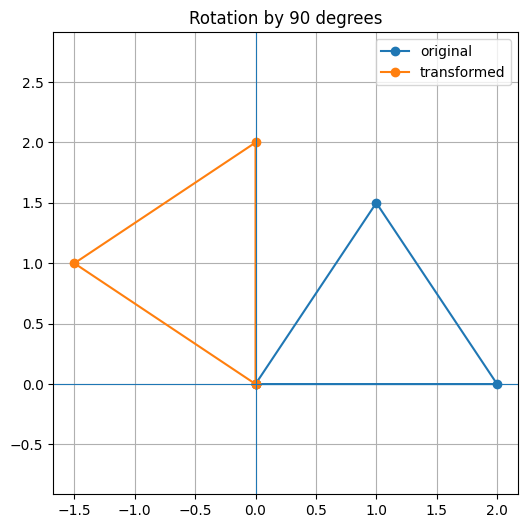

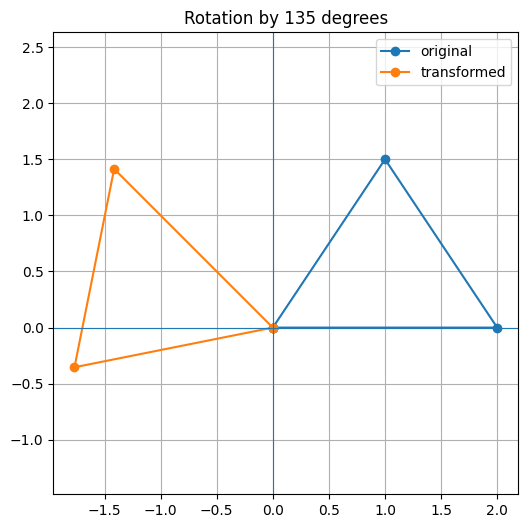

In [11]:
def rotation(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

triangle = np.array([[0, 0], [2, 0], [1, 1.5], [0, 0]], dtype=float)

for deg in [0, 30, 60, 90, 135]:
    Q = rotation(np.deg2rad(deg))
    plot_shape_transform(Q, triangle, f"Rotation by {deg} degrees")


## 7. Feature mixing: a matrix in data science

Each row below represents a student using three features:

1. study hours;
2. sleep hours;
3. practice problems completed.

A matrix can transform these raw features into new features.

In [12]:
X = np.array([
    [4, 7, 20],
    [8, 5, 35],
    [2, 8, 10],
    [6, 6, 25],
    [9, 4, 45]
], dtype=float)

feature_names = ["study", "sleep", "practice"]

M = np.array([
    [0.35, 0.15, 0.50],   # preparedness
    [0.20, 0.60, 0.20]    # balance
])

Y = X @ M.T
print("Transformed features:")
print(Y)


Transformed features:
[[12.45  9.  ]
 [21.05 11.6 ]
 [ 6.9   7.2 ]
 [15.5   9.8 ]
 [26.25 13.2 ]]


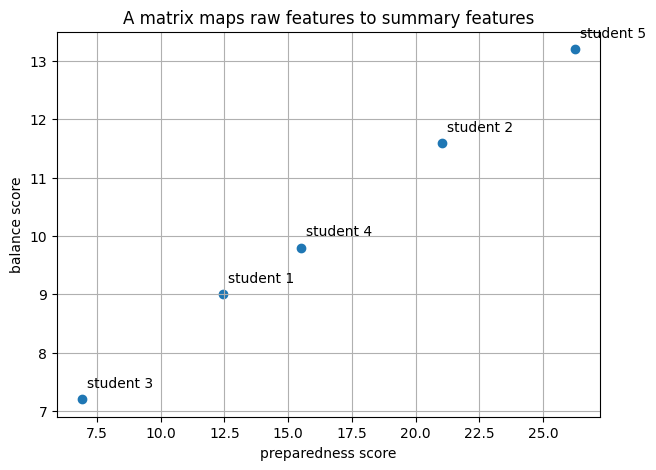

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(Y[:,0], Y[:,1])
for i in range(len(Y)):
    plt.text(Y[i,0]+0.2, Y[i,1]+0.2, f"student {i+1}")
plt.xlabel("preparedness score")
plt.ylabel("balance score")
plt.title("A matrix maps raw features to summary features")
plt.grid(True)
plt.show()


### Student task

The weights above may not be ideal because practice-problem counts are much larger than sleep hours.  Standardize `X` first, then apply a matrix.  How does the plot change?

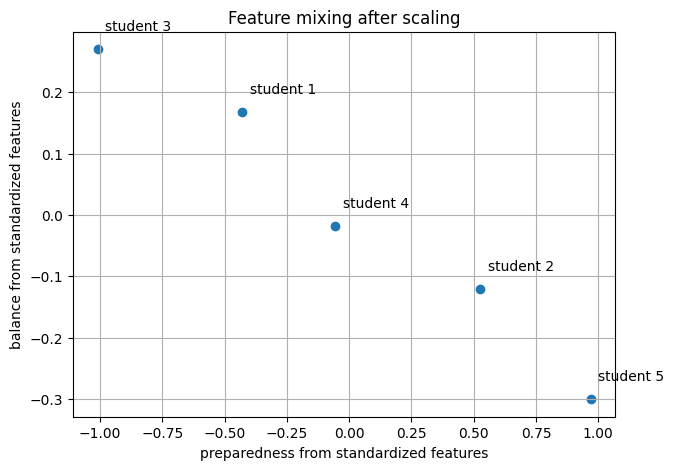

In [14]:
X_centered = X - X.mean(axis=0)
X_scaled = X_centered / X.std(axis=0)
Y_scaled = X_scaled @ M.T

plt.figure(figsize=(7,5))
plt.scatter(Y_scaled[:,0], Y_scaled[:,1])
for i in range(len(Y_scaled)):
    plt.text(Y_scaled[i,0]+0.03, Y_scaled[i,1]+0.03, f"student {i+1}")
plt.xlabel("preparedness from standardized features")
plt.ylabel("balance from standardized features")
plt.title("Feature mixing after scaling")
plt.grid(True)
plt.show()


## 8. Information loss

A projection can collapse many inputs to the same output.

In [15]:
P = np.array([[1, 0],
              [0, 0]])

points = np.array([[2, 1], [2, 3], [2, -2], [-1, 4], [-1, -3]], dtype=float)
projected = points @ P.T

print("Original points:")
print(points)
print("Projected points:")
print(projected)


Original points:
[[ 2.  1.]
 [ 2.  3.]
 [ 2. -2.]
 [-1.  4.]
 [-1. -3.]]
Projected points:
[[ 2.  0.]
 [ 2.  0.]
 [ 2.  0.]
 [-1.  0.]
 [-1.  0.]]


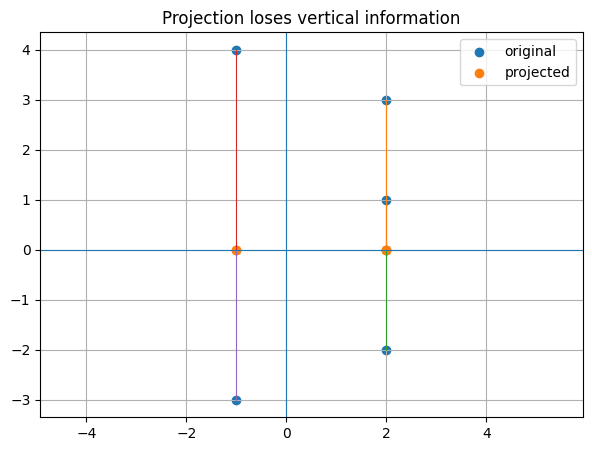

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(points[:,0], points[:,1], label='original')
plt.scatter(projected[:,0], projected[:,1], label='projected')
for p, q in zip(points, projected):
    plt.plot([p[0], q[0]], [p[1], q[1]], linewidth=0.8)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.title("Projection loses vertical information")
plt.show()


## 9. Image as vector, matrix as image transformer

We create a simple synthetic image and apply transformations to its coordinates.

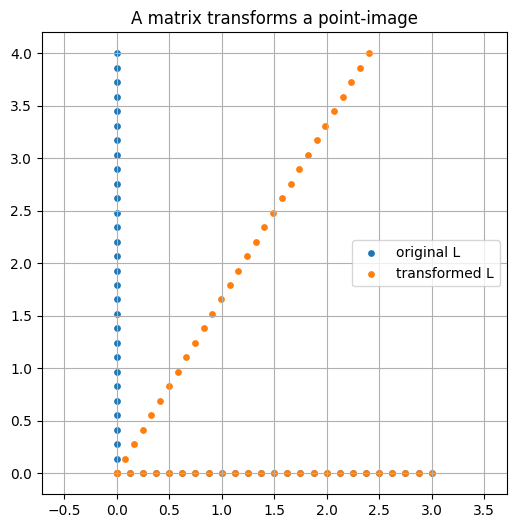

In [17]:
# Create a small set of points shaped like a letter L
pts = []
for y in np.linspace(0, 4, 30):
    pts.append([0, y])
for x in np.linspace(0, 3, 25):
    pts.append([x, 0])
pts = np.array(pts)

A = np.array([[1, 0.6],
              [0, 1]])
T = pts @ A.T

plt.figure(figsize=(6,6))
plt.scatter(pts[:,0], pts[:,1], s=15, label='original L')
plt.scatter(T[:,0], T[:,1], s=15, label='transformed L')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("A matrix transforms a point-image")
plt.show()


## 10. High-dimensional matrix machines

In high dimensions, a matrix can mix many coordinates at once.  The geometry is harder to draw, but the same rule holds.

An $m 	imes n$ matrix maps $\mathbb{R}^n$ to $\mathbb{R}^m$.

In [18]:
rng = np.random.default_rng(7)

n = 100   # input dimension
m = 10    # output dimension
A = rng.normal(size=(m, n)) / np.sqrt(n)

X = rng.normal(size=(500, n))
Y = X @ A.T

input_norms = np.linalg.norm(X, axis=1)
output_norms = np.linalg.norm(Y, axis=1)

print("Average input norm:", input_norms.mean())
print("Average output norm:", output_norms.mean())
print("Input dimension:", n)
print("Output dimension:", m)


Average input norm: 9.95247763158688
Average output norm: 2.9074644570027566
Input dimension: 100
Output dimension: 10


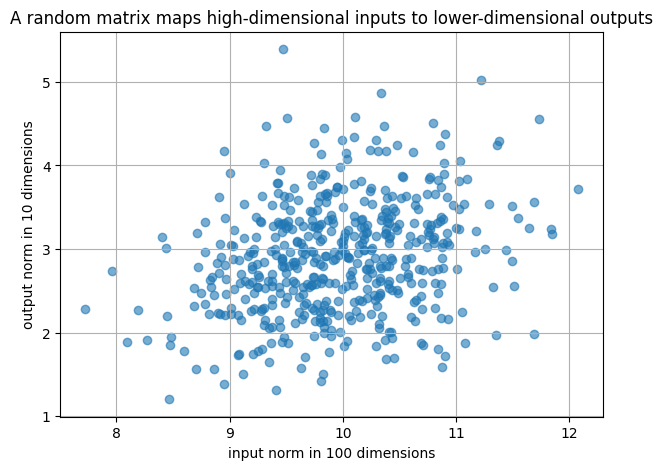

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(input_norms, output_norms, alpha=0.6)
plt.xlabel("input norm in 100 dimensions")
plt.ylabel("output norm in 10 dimensions")
plt.title("A random matrix maps high-dimensional inputs to lower-dimensional outputs")
plt.grid(True)
plt.show()


### Reflection

1. What information might be lost when mapping from $\mathbb{R}^{100}$ to $\mathbb{R}^{10}$?
2. Why might a data scientist still want to do this?
3. How is this connected to compression, feature extraction, and neural networks?

## 11. Mini-project: build your own matrix machine

Choose one of the following:

### Option A: Geometry machine
Create a matrix that transforms a square into a shape of your choice.  Explain how each column affects the result.

### Option B: Feature machine
Create a small dataset with at least $5$ rows and $4$ features.  Design a matrix that turns the raw features into $2$ summary features.  Visualize the result.

### Option C: Image machine
Create a point cloud shaped like a letter or simple object.  Apply a sequence of matrices to rotate, scale, and shear it.

Your final answer should include:

- the matrix or matrices you used;
- a visualization;
- a paragraph explaining what the matrix does;
- one sentence connecting your work to the idea of a matrix as a machine.